## Decision Trees - Intro and Regression

Decision Trees are supervised machine learning algorithms that are used for both regression and classification tasks. Trees are powerful algorithms that can handle complex datasets.

Here are 7 interesting facts about decision trees:

1. They do not need the numerical input data to be scaled. Whatever the numerical values are, decision trees don't care.

2. Decision trees handle categorical features in the raw text format (Scikit-Learn doesn't support this, TensorFlow's trees implementation does).

3. Different to other complex learning algorithms, the results of decision trees can be interpreted. It's fair to say that decision trees are not blackbox type models.

4. While most models will suffer from missing values, decision trees are okay with them.

5. Trees can handle imbalanced datasets. You will only have to adjust the weights of the classes.

6. Trees can provide the feature importances or how much each feature contributed to the model training results.

7. Trees are the basic building blocks of ensemble methods such as random forests and gradient boosting machines.

The way decision trees works is like the series of if/else questions. Let's say that you want to make a decision of the car to buy. In order to get the right car to buy, you could go on and evaluate the level of the safety, the number of sits and doors by asking series of if like questions.

A well-known downside of decision trees is that they tend to overfit the data easily(pretty much assumed they will always overfit at first). One way to overcome overfitting is to reduce the maximum depth of the decision tree (refered to as `max_depth` hyperparameter) in decision trees. We will see other techniques to avoid overfitting.

To motivate the superpower of decision trees, let's use it for a regression task where instead of predicting class, we are predicting a continous value. In the next lab, we will use them for classification.

## Decision Trees for Regression

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import matplotlib.pyplot as plt
%matplotlib inline

## Loading the data

In this regression task with decision trees, we will use the Machine CPU (Central Processing Unit) data which is avilable at [OpenML](https://www.openml.org/search?type=data&status=active&id=230). We will load it with Sklearn fetch_openml function.

If you are reading this, it's very likely that you know CPU or you have once(or many times) thought about it when you were buying your computer. In this notebook, we will predict the relative performance of the CPU given the following data:

* MYCT: machine cycle time in nanoseconds (integer)
* MMIN: minimum main memory in kilobytes (integer)
* MMAX: maximum main memory in kilobytes (integer)
* CACH: cache memory in kilobytes (integer)
* CHMIN: minimum channels in units (integer)
* CHMAX: maximum channels in units (integer)
* PRP: published relative performance (integer) (target variable)

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [9]:
from sklearn.datasets import fetch_openml
machine_cpu=fetch_openml(name='machine_cpu')
type(machine_cpu)

sklearn.utils._bunch.Bunch

In [10]:
machine_cpu.data.shape

(209, 6)

In [13]:
print(machine_cpu.DESCR)

**Author**:   
**Source**: Unknown -   
**Please cite**:   

The problem concerns Relative CPU Performance Data. More information can be obtained in the UCI Machine
 Learning repository (http://www.ics.uci.edu/~mlearn/MLSummary.html).
 The used attributes are :
 MYCT: machine cycle time in nanoseconds (integer)
 MMIN: minimum main memory in kilobytes (integer)
 MMAX: maximum main memory in kilobytes (integer)
 CACH: cache memory in kilobytes (integer)
 CHMIN: minimum channels in units (integer)
 CHMAX: maximum channels in units (integer)
 PRP: published relative performance (integer) (target variable)
 
 Original source: UCI machine learning repository. 
 Source: collection of regression datasets by Luis Torgo (ltorgo@ncc.up.pt) at
 http://www.ncc.up.pt/~ltorgo/Regression/DataSets.html
 Characteristics: 209 cases; 6 continuous variables

Downloaded from openml.org.


In [26]:
machine_cpu.frame.head()

,MYCT,MMIN,MMAX,CACH,CHMIN,CHMAX,class
0,125,256,6000,256,16,128,198
1,29,8000,32000,32,8,32,269
2,29,8000,32000,32,8,32,220
3,29,8000,32000,32,8,32,172
4,29,8000,16000,32,8,16,132


In [39]:
# machine_cpu.details
machine_cpu.data.columns
#or
machine_cpu.feature_names


['MYCT', 'MMIN', 'MMAX', 'CACH', 'CHMIN', 'CHMAX']

In [42]:
machine_cpu.frame['class']
# or
machine_cpu.target

0      198
1      269
2      220
3      172
4      132
      ... 
204     42
205     46
206     52
207     67
208     45
Name: class, Length: 209, dtype: int64

In [47]:
machine_data=machine_cpu.data
machine_labels=machine_cpu.target
type(machine_data),type(machine_labels)

(pandas.core.frame.DataFrame, pandas.core.series.Series)

## EDA

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(machine_data,machine_labels,test_size=0.2,random_state=20)


print('The size of training data is: {} \nThe size of testing data is: {}'.format(len(X_train), len(X_test)))

The size of training data is: 167 
The size of testing data is: 42


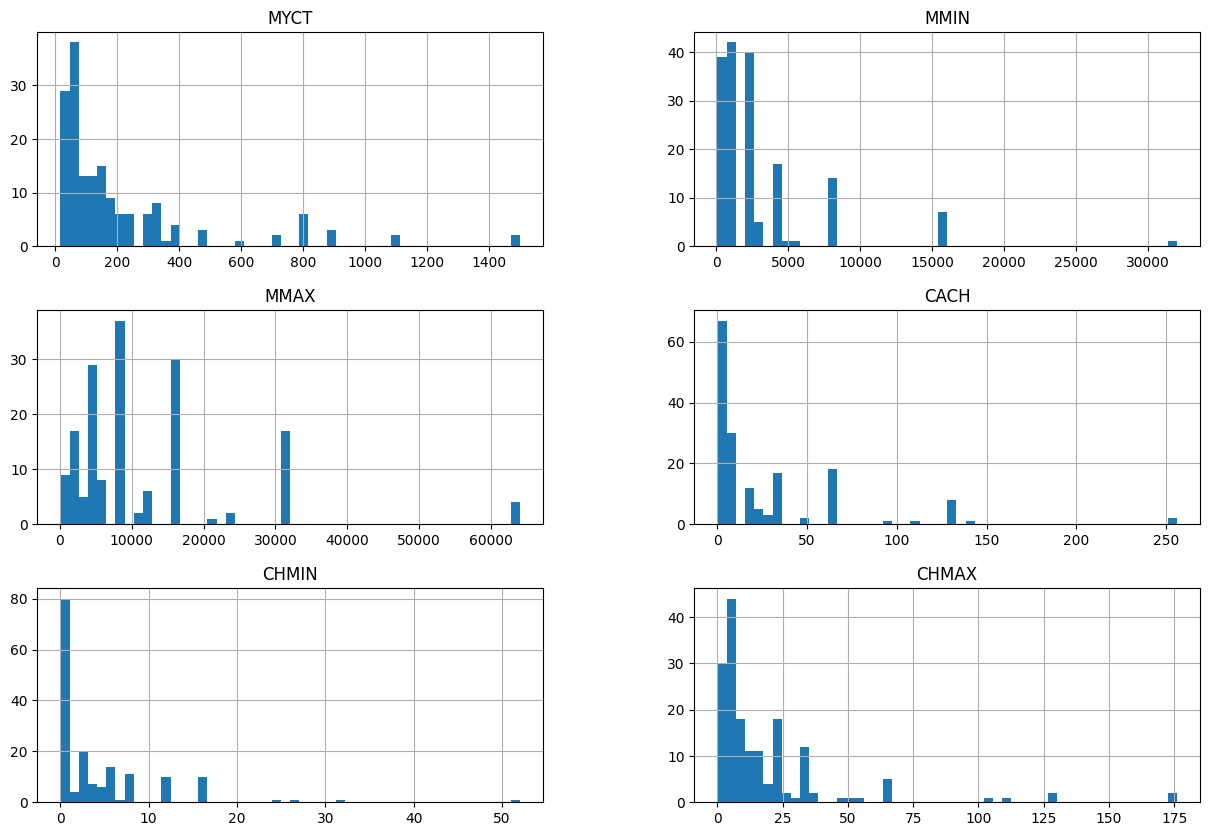

In [50]:
X_train.hist(bins=50,figsize=(15,10))
plt.show()

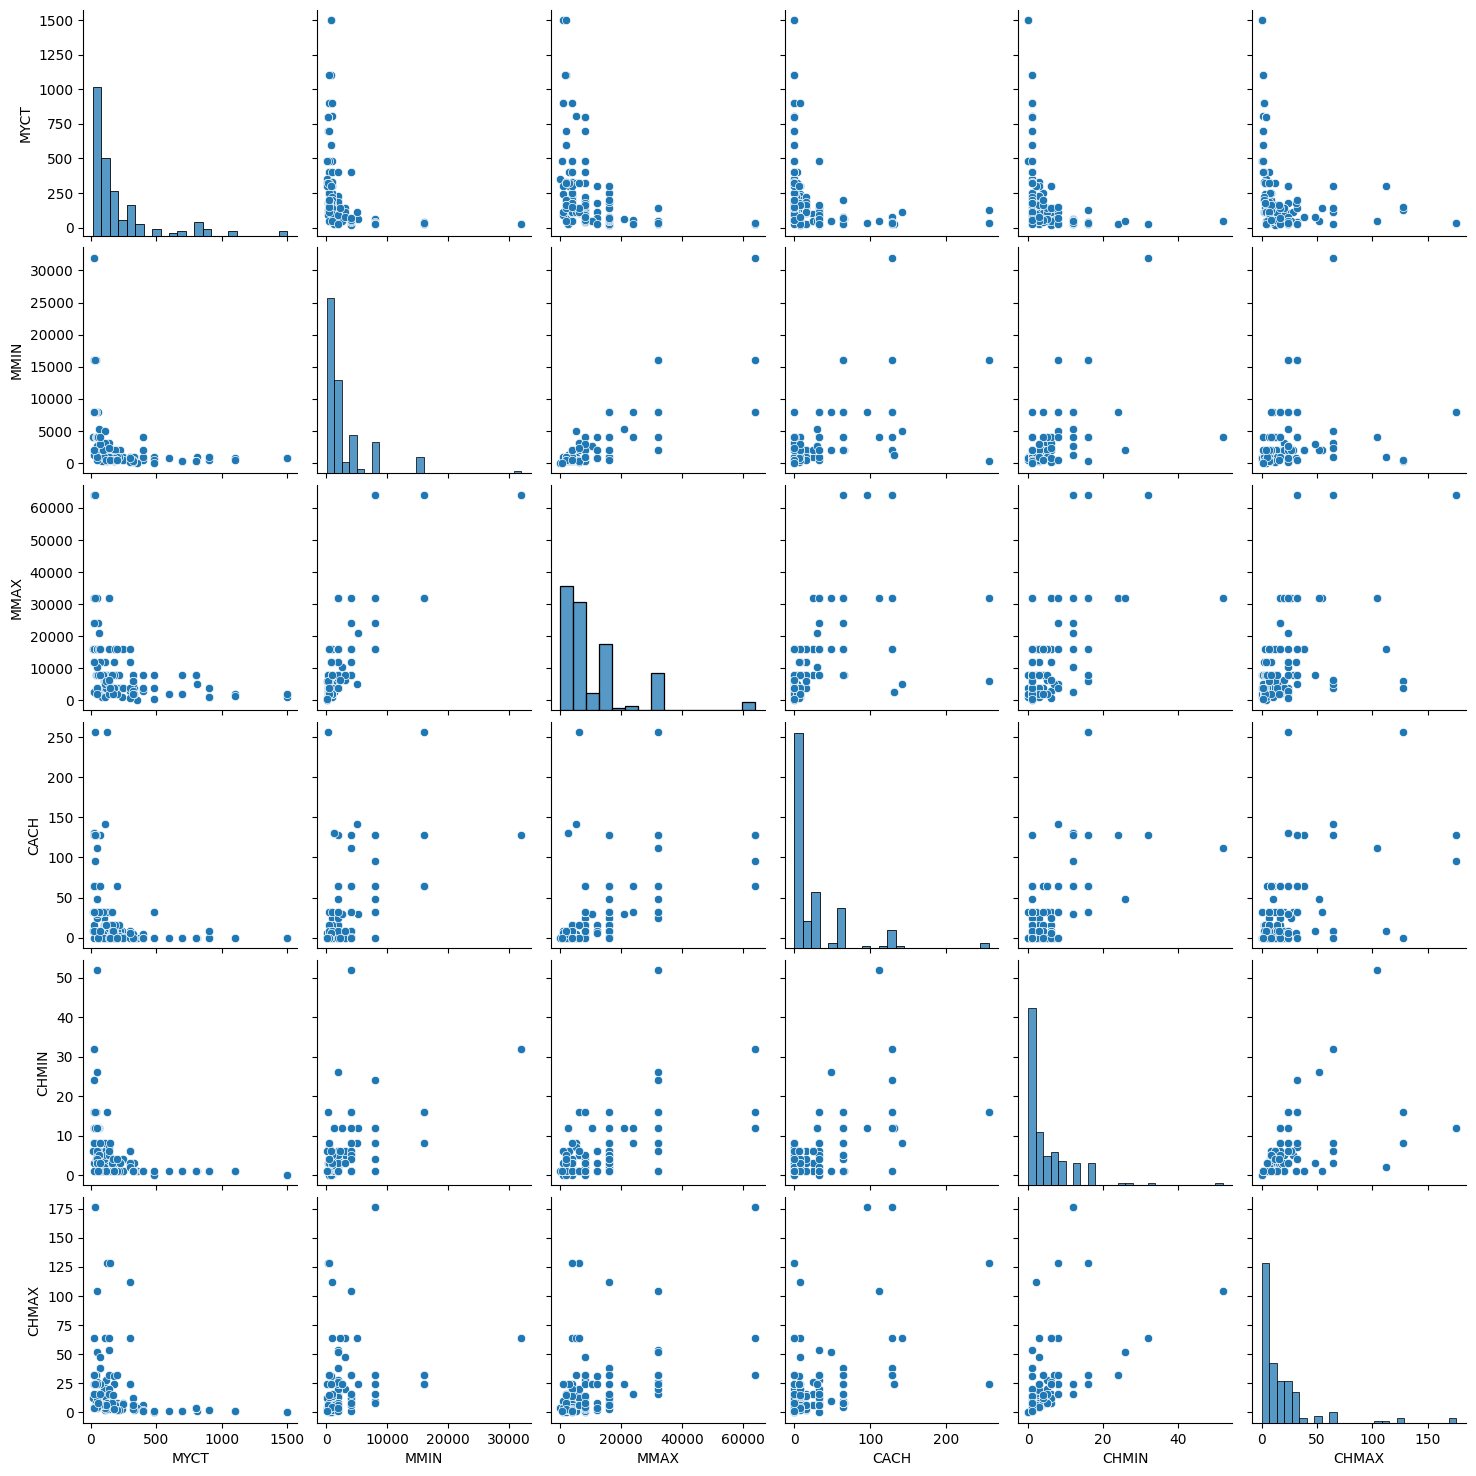

In [51]:
sns.pairplot(X_train)

In [53]:
X_train.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
MYCT,167.0,207.958084,266.772823,17.0,50.0,110.0,232.5,1500.0
MMIN,167.0,2900.826347,4165.950964,64.0,768.0,2000.0,3100.0,32000.0
MMAX,167.0,11761.161677,12108.332354,64.0,4000.0,8000.0,16000.0,64000.0
CACH,167.0,26.071856,42.410014,0.0,0.0,8.0,32.0,256.0
CHMIN,167.0,4.760479,6.487439,0.0,1.0,2.0,6.0,52.0
CHMAX,167.0,18.616766,27.489919,0.0,5.0,8.0,24.0,176.0


In [54]:
X_train.isnull().sum()

MYCT     0
MMIN     0
MMAX     0
CACH     0
CHMIN    0
CHMAX    0
dtype: int64

### Data Preprocessing

It is here that we prepare the data to be in the proper format for the machine learning model.

Decision trees don't care if the features are scaled or not. Let's set up a pipeline to scale features, and we will use it to verify that notion.

In [55]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

scale_pipe = Pipeline([
    ('scaler', StandardScaler())
    
])

X_train_scaled = scale_pipe.fit_transform(X_train)

### Training Decision Tree Regressor

In [57]:
from sklearn.tree import DecisionTreeRegressor

tree_reg= DecisionTreeRegressor()
tree_reg.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


Let's train the same model on the scaled data.

In [58]:
tree_reg_scaled=DecisionTreeRegressor()
tree_reg_scaled.fit(X_train_scaled,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


## Evaluating Decision Trees

Let's first check the root mean squared error on the training. It is not advised to evaluate the model on the test data since we haven't improved it yet. I will make a function to make it easier and to avoid repetitions.

In [59]:
from sklearn.metrics import mean_squared_error

def predict(input_data,model,labels):
    preds = model.predict(input_data)
    mse = mean_squared_error(labels,preds)
    rmse = np.sqrt(mse)
    rmse
    
    return rmse

In [60]:
predict(X_train,tree_reg,y_train)

np.float64(9.724590719956222)

In [61]:
predict(X_train_scaled,tree_reg_scaled,y_train)

np.float64(9.724590719956222)

As you can see, there is no difference at all. So in your future projects using decision trees, whether you scale the data or not, your predictions will not be affected.

But never do this ...

In [62]:
predict(X_train_scaled, tree_reg, y_train)

np.float64(196.28992976448413)

If you can inspect the parameters that I passed in predict function above, there are scaled data, model trained on unscaled data, and labels(y_train). As you may have guessed, that is a complete mismatch which led to poor results. If you trained a model on scaled data, the data that you predict the model on should be scaled in the same way too.

Let's try to improve the model.

## Improving Decision Trees

In [64]:
tree_reg.get_params()

{'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

We have seen that one way to improve the decision tree model is to find the right number of max_depth and some other few parameters. Let's use GridSearch to find best hyperparameters. Note that this may end up overfitting because we have a small dataset. But since we are doing this for learning purpose (you can adapt it to your problem), let's do it.

In [65]:
from sklearn.model_selection import GridSearchCV

params_grid = {'max_leaf_nodes': list(range(0, 10)), 'min_samples_split': [0,1,2, 3, 4], 
              'max_depth':[None,0,1,2,3]}

#refit is true by default. The best estimator is trained on the whole dataset 

grid_search = GridSearchCV(DecisionTreeRegressor(random_state=42), params_grid, verbose=1, cv=3, refit=True)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 250 candidates, totalling 750 fits


,estimator,DecisionTreeR...ndom_state=42)
,param_grid,"{'max_depth': [None, 0, ...], 'max_leaf_nodes': [0, 1, ...], 'min_samples_split': [0, 1, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [66]:
grid_search.best_params_

{'max_depth': None, 'max_leaf_nodes': 9, 'min_samples_split': 4}

In [68]:
tree_best=grid_search.best_estimator_

In [69]:
predict(X_train,tree_best,y_train)

np.float64(34.999530266023044)

Like we said, we overfitted. The RMSE on our small dataset was pretty enough (and you probably would not use decision trees for small data like this we are using).

Finally we can evaluate the model on the test set. Let's use the orginal model.

In [70]:
predict(X_test,tree_reg,y_test)

np.float64(42.80638859752017)

Clearly, the model overfitted and the improvements we tried didn't improve anything. This is not an issue of the model or our approach to improve the model. Decision trees are complex models for the data we have.